# GNN 기반 사기 리뷰 탐지 — [3-1] 리뷰 단어 네트워크 분석 (EDA)

이 노트북은 리뷰 텍스트 내의 단어를 노드로 하는 네트워크 분석을 수행합니다.

### 분석 목적:
1. **텍스트 구조 분석**: 리뷰 내 단어들의 연결 구조(네트워크) 파악
2. **HIN 모델링 기초**: 이후 Heterogeneous Information Network(HIN) 구축 시 단어 노드 간의 관계를 정의하기 위한 사전 지표 확보

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import community as community_louvain
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from collections import Counter
import itertools
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from common_utils import load_data, setup_plotting
import warnings

warnings.filterwarnings("ignore")
setup_plotting()
nltk.download(['punkt', 'stopwords', 'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng', 'punkt_tab'], quiet=True)

df = load_data("yelpzip_sampled.parquet")
print(f"Total reviews: {len(df):,}")

# ── Option B 시간 기반 분리 (다른 노트북과 동일 기준 — 누수 방지) ─────────────
# 어휘 선정·PMI 네트워크·변별 어휘 300개·TF-IDF IDF 계산이 모두
# train 기준이어야 custom_edges_textSim.csv 와 features_text_vocab.csv 에 누수가 없음
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
N = len(df)
labels_arr = df['label'].values

best_idx, best_diff = None, float('inf')
for cutoff in range(int(N * 0.72), int(N * 0.88)):
    tr_ratio = labels_arr[:cutoff].mean()
    te_ratio = labels_arr[cutoff:].mean()
    diff = abs(tr_ratio - te_ratio)
    if diff < best_diff:
        best_diff, best_idx = diff, cutoff

idx_trainval = np.arange(best_idx)
idx_test     = np.arange(best_idx, N)
idx_train, _ = train_test_split(
    idx_trainval, test_size=0.20, random_state=42, stratify=labels_arr[idx_trainval]
)
df['_is_train'] = False
df.loc[idx_train, '_is_train'] = True

cutoff_date = df.iloc[best_idx]['date'].date()
print(f"시간 분리 기준일: {cutoff_date}  (사기 비율 차이: {best_diff:.4f})")
print(f"Train 사기 비율: {labels_arr[idx_train].mean():.3f} | "
      f"Test  사기 비율: {labels_arr[idx_test].mean():.3f}")
print(f"Train: {df['_is_train'].sum():,} / Test: {(~df['_is_train']).sum():,}")

Plotting setup complete for Windows (Font: Malgun Gothic)
Total reviews: 50,950
시간 분리 기준일: 2014-06-28  (사기 비율 차이: 0.0467)
Train 사기 비율: 0.235 | Test  사기 비율: 0.282
Train: 29,392 / Test: 21,558


## 1. 텍스트 정제 및 유의미한 노드 선별 (Noise Reduction)
네트워크가 너무 거대해지면 분석이 불가능하므로, **정보량이 높은 단어**들만 네트워크의 노드로 사용합니다.

- **품사 필터링**: 명사(NN), 형용사(JJ), 동사(VB) 추출
- **중요도 필터링**: 전체 50,950개 리뷰에서 **100회 이상** 등장한 단어만 선별 (전체 42,827개 중 2,826개)

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if not isinstance(text, str): return ""
    tokens = word_tokenize(text.lower())
    tagged = pos_tag(tokens)
    selected_words = [word for word, tag in tagged 
                      if (tag.startswith('NN') or tag.startswith('JJ') or tag.startswith('VB')) 
                      and word not in stop_words and word.isalpha() and len(word) > 2]
    return " ".join(selected_words)

# 텍스트 전처리는 전체 노드 대상 (엣지 생성 시 전체 리뷰가 필요)
print("데이터 전처리 중... (품사 필터링, 전체 노드 대상)")
df_sample = df.copy()
df_sample['clean_text'] = df_sample['text'].apply(preprocess_text)

# 어휘 빈도 계산: train 행만 사용 — 누수 방지
# test 리뷰의 어휘가 단어 선별 기준에 영향을 주지 않도록 차단
print("핵심 단어 선별 중... (train 행 기준 빈도 100회 이상)")
from collections import Counter as _Counter
_all_words = []
for _text in df_sample[df_sample['_is_train']]['clean_text']:
    _all_words.extend(_text.split())
_freq = _Counter(_all_words)
top_words = [w for w, cnt in _freq.items() if cnt >= 100]

print(f"전체 어휘(train 기준): {len(_freq):,}개")
print(f"100회 이상 등장: {len(top_words):,}개 (전체의 {len(top_words)/len(_freq)*100:.1f}%)")
print(f"최종 분석 노드 수: {len(top_words)}개")

데이터 전처리 중... (품사 필터링, 전체 노드 대상)
핵심 단어 선별 중... (train 행 기준 빈도 100회 이상)
전체 어휘(train 기준): 33,982개
100회 이상 등장: 2,011개 (전체의 5.9%)
최종 분석 노드 수: 2011개


## 2. 엣지(Edge) 정의 및 가중치(Weight) 연산
단어 간의 관계를 단순 빈도가 아닌 **PMI(Pointwise Mutual Information)**로 정의합니다.

In [3]:
def build_pmi_network(docs, vocab, min_count=5):
    word_counts = Counter()
    cooc_counts = Counter()
    total_docs = len(docs)
    vocab_set = set(vocab)
    
    for doc in docs:
        words = sorted(list(set(doc.split()) & vocab_set))
        for word in words:
            word_counts[word] += 1
        for w1, w2 in itertools.combinations(words, 2):
            cooc_counts[(w1, w2)] += 1
            
    G = nx.Graph()
    for (w1, w2), count in cooc_counts.items():
        if count < min_count: continue
        p_w1_w2 = count / total_docs
        p_w1 = word_counts[w1] / total_docs
        p_w2 = word_counts[w2] / total_docs
        pmi = np.log(p_w1_w2 / (p_w1 * p_w2))
        if pmi > 0:
            G.add_edge(w1, w2, weight=pmi)
    return G

# PMI 네트워크: train 행만 사용 — 누수 방지
print("train 샘플에 대한 단어 네트워크 생성 중...")
G_full = build_pmi_network(
    list(df_sample[df_sample['_is_train']]['clean_text']),
    top_words, min_count=30
)
print(f"네트워크 구축 완료: 노드 {G_full.number_of_nodes()}개, 엣지 {G_full.number_of_edges()}개")

train 샘플에 대한 단어 네트워크 생성 중...
네트워크 구축 완료: 노드 2009개, 엣지 207556개


## 3-1. 중심성 기반 노드 필터링 및 중복 키워드 제거

2,826개 어휘 전체로 만든 PMI 네트워크에서 **유의미한 노드만** 추려 어휘를 압축합니다.

1. **고립 노드 제거**: 공동출현 엣지가 없는 단어 제거
2. **중심성 필터링**: 연결 중심성 **70th 백분위 이상** 상위 30% 코어 어휘만 유지 (근거: 도수분포 시각화로 자연 분리점 확인)
3. **중복 어형 제거**: 같은 어간(stem)의 단어 중 빈도 낮은 쪽 제거 (예: noodle/noodles)
4. **필터링된 어휘로 G_full 재구성** → 이후 허브 제거 / 사기-정상 분리 프로세스 동일 적용

초기 네트워크: 노드 2,009개, 엣지 207,556개

[Step 1] 고립 노드 제거: 0개
  남은 노드: 2,009개


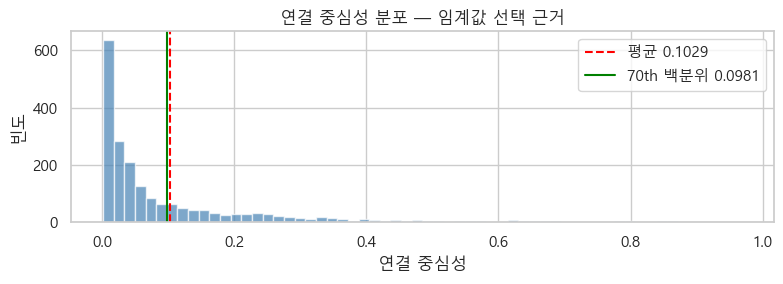


[Step 2] 연결 중심성 필터링 (70th 백분위 기준)
  임계값: 0.09811  (상위 30% 코어 어휘만 유지)
  제거: 1403개  남은 노드: 606개

[Step 3] 어간 중복 제거: 103개 제거
  제거 예시: ['appetizers', 'ask', 'bites', 'bun', 'burgers', 'call', 'cocktail', 'comes', 'coming', 'crowd', 'days', 'desserts', 'disappointing', 'dishes', 'drink']

=== 필터링 결과 ===
  2,826개 → 고립/저중심성 제거 → 중복 제거 → 최종 503개
G_full 재구성 중...
재구성 완료: 노드 503개, 엣지 110,438개


In [4]:
print(f"초기 네트워크: 노드 {G_full.number_of_nodes():,}개, 엣지 {G_full.number_of_edges():,}개")

# ── Step 1: 고립 노드 제거 ────────────────────────────────────────────
isolated = [n for n in G_full.nodes() if G_full.degree(n) == 0]
G_full.remove_nodes_from(isolated)
print(f"\n[Step 1] 고립 노드 제거: {len(isolated)}개")
print(f"  남은 노드: {G_full.number_of_nodes():,}개")

# ── Step 2: 연결 중심성 필터링 (70th 백분위 — 상위 30% 코어 어휘 유지) ──────
degree_cent_init = nx.degree_centrality(G_full)
cent_vals = list(degree_cent_init.values())

# 도수분포 시각화로 임계값 선택 근거 확인
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(cent_vals, bins=60, color='steelblue', alpha=0.7)
ax.axvline(float(np.mean(cent_vals)),
           color='red',   linestyle='--',
           label=f'평균 {np.mean(cent_vals):.4f}')
ax.axvline(float(np.percentile(cent_vals, 70)),
           color='green', linestyle='-',
           label=f'70th 백분위 {np.percentile(cent_vals, 70):.4f}')
ax.set_xlabel("연결 중심성")
ax.set_ylabel("빈도")
ax.set_title("연결 중심성 분포 — 임계값 선택 근거")
ax.legend()
plt.tight_layout()
plt.show()

cent_threshold   = float(np.percentile(cent_vals, 70))
meaningful_nodes = [n for n, c in degree_cent_init.items() if c >= cent_threshold]
removed_low_cnt  = G_full.number_of_nodes() - len(meaningful_nodes)
print(f"\n[Step 2] 연결 중심성 필터링 (70th 백분위 기준)")
print(f"  임계값: {cent_threshold:.5f}  (상위 30% 코어 어휘만 유지)")
print(f"  제거: {removed_low_cnt}개  남은 노드: {len(meaningful_nodes)}개")

# ── Step 3: 어간 중복 키워드 제거 (Porter Stemmer) ────────────────────
from nltk.stem import PorterStemmer
_ps = PorterStemmer()
stem_groups = {}
for word in meaningful_nodes:
    stem_groups.setdefault(_ps.stem(word), []).append(word)

deduped, removed_dup = [], []
for words in stem_groups.values():
    best = max(words, key=lambda w: _freq.get(w, 0))
    deduped.append(best)
    removed_dup.extend([w for w in words if w != best])

print(f"\n[Step 3] 어간 중복 제거: {len(removed_dup)}개 제거")
if removed_dup:
    print(f"  제거 예시: {sorted(removed_dup)[:15]}")

# ── 최종 어휘 확정 및 G_full 재구성 ─────────────────────────────────
top_words = deduped
print(f"\n=== 필터링 결과 ===")
print(f"  2,826개 → 고립/저중심성 제거 → 중복 제거 → 최종 {len(top_words)}개")

print("G_full 재구성 중...")
G_full = build_pmi_network(df_sample["clean_text"], top_words, min_count=30)
print(f"재구성 완료: 노드 {G_full.number_of_nodes():,}개, 엣지 {G_full.number_of_edges():,}개")

## 3-2. 초거대 허브 제거 및 네트워크 중심성 시각화

제거된 초거대 허브 단어 (291개): ['best', 'good', 'come', 'couple', 'going', 'least', 'love', 'stars', 'try', 'added', 'appetizer', 'cooked', 'decent', 'delicious', 'everything', 'feel', 'fish', 'food', 'fresh', 'get', 'got', 'large', 'like', 'little', 'minutes', 'nice', 'open', 'overall', 'pretty', 'price', 'right', 'service', 'someone', 'table', 'took', 'amazing', 'anything', 'back', 'big', 'bit', 'day', 'different', 'enjoyed', 'half', 'huge', 'room', 'salad', 'special', 'think', 'top', 'want', 'dining', 'dinner', 'door', 'fine', 'items', 'kind', 'lot', 'make', 'menu', 'place', 'recommend', 'see', 'small', 'staff', 'super', 'sure', 'sweet', 'wait', 'better', 'let', 'people', 'real', 'tasty', 'hot', 'meat', 'nothing', 'ordered', 'restaurant', 'shrimp', 'time', 'add', 'bar', 'choice', 'city', 'drinks', 'experience', 'extra', 'find', 'flavor', 'found', 'friendly', 'give', 'given', 'happy', 'leave', 'light', 'looking', 'made', 'many', 'meal', 'mouth', 'need', 'new', 'nyc', 'quality', 'salty', 'sauc

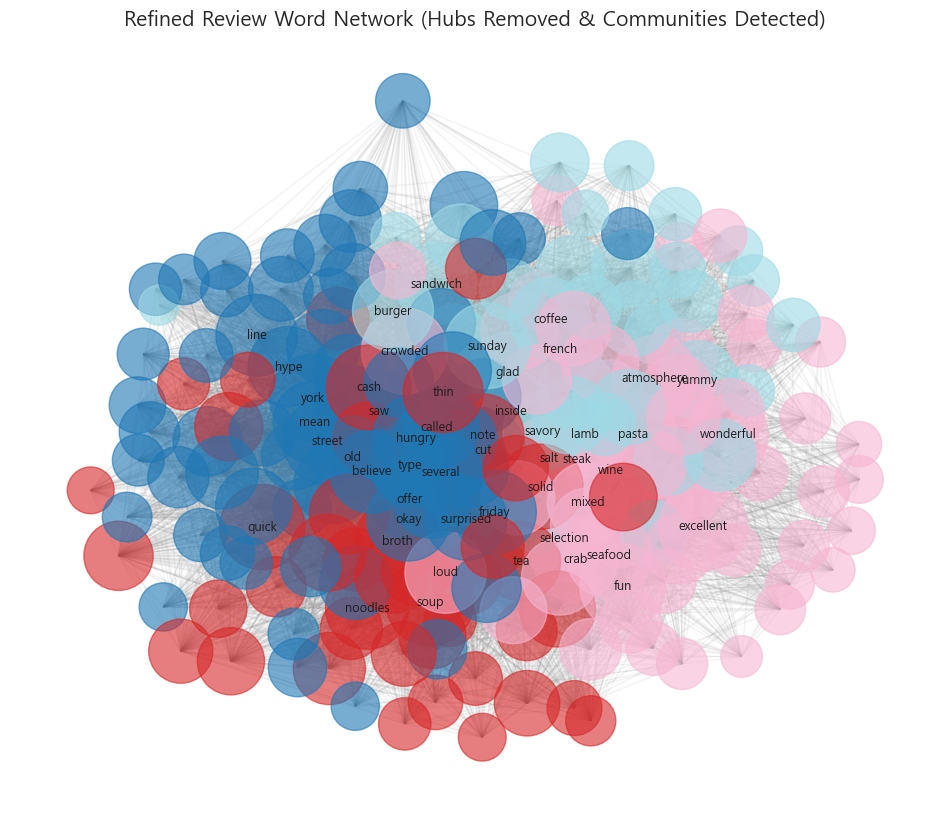


사기/정상 분리 네트워크 구축 중... (train 데이터만 사용)
  사기 리뷰(train): 6,920개 | 정상 리뷰(train): 22,472개
  사기 네트워크  — 노드 503개, 엣지 30737개
  정상 네트워크  — 노드 503개, 엣지 115743개
사기/정상 분리 고유벡터 중심성 계산 완료


In [5]:
if G_full.number_of_nodes() > 0:
    # 1. 초기 연결 중심성 계산 및 초거대 허브 제거
    degree_cent = nx.degree_centrality(G_full)
    high_degree_nodes = [node for node, cent in degree_cent.items() if cent >= 0.9]
    print(f"제거된 초거대 허브 단어 ({len(high_degree_nodes)}개): {high_degree_nodes}")
    G_full.remove_nodes_from(high_degree_nodes)

    if G_full.number_of_nodes() > 0:
        # 2. 중심성 지표 재계산
        degree_cent  = nx.degree_centrality(G_full)
        between_cent = nx.betweenness_centrality(G_full, weight='weight')
        try:
            eigen_cent = nx.eigenvector_centrality(G_full, weight='weight', max_iter=1000)
        except:
            eigen_cent = nx.eigenvector_centrality_numpy(G_full, weight='weight')

        # 3. Louvain 커뮤니티 탐지
        try:
            partition = community_louvain.best_partition(G_full, weight='weight')
            nx.set_node_attributes(G_full, partition, 'community')
            print(f"탐지된 단어 커뮤니티 수: {len(set(partition.values()))}개")
        except:
            print("Warning: 커뮤니티 탐지 실패")
            partition = {}

        def print_top_nodes(cent_dict, name, n=10):
            print(f"--- Top {n} {name} ---")
            for word, val in sorted(cent_dict.items(), key=lambda x: x[1], reverse=True)[:n]:
                print(f"  {word}: {val:.4f}")
            print()

        print_top_nodes(degree_cent,  "연결 중심성 (Degree)")
        print_top_nodes(between_cent, "매개 중심성 (Betweenness)")
        print_top_nodes(eigen_cent,   "고유벡터 중심성 (Eigenvector)")

        # 4. 전체 네트워크 시각화
        plt.figure(figsize=(12, 10))
        pos = nx.spring_layout(G_full, k=0.2, iterations=30)
        if partition:
            node_colors = [partition[node] for node in G_full.nodes()]
            cmap = plt.cm.get_cmap('tab20')
        else:
            node_colors = 'skyblue'
            cmap = None
        node_sizes   = [v * 5000 for v in degree_cent.values()]
        top_50_nodes = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:50]
        labels       = {node: node for node, _ in top_50_nodes}
        nx.draw_networkx_nodes(G_full, pos, node_size=node_sizes, node_color=node_colors, cmap=cmap, alpha=0.6)
        nx.draw_networkx_edges(G_full, pos, alpha=0.1, edge_color='gray')
        nx.draw_networkx_labels(G_full, pos, labels=labels, font_size=9, font_family=plt.rcParams['font.family'][0])
        plt.title("Refined Review Word Network (Hubs Removed & Communities Detected)", fontsize=15)
        plt.axis('off')
        plt.show()

        # 5. 사기/정상 분리 네트워크 구축 — train 행만 사용 (누수 방지)
        print("\n사기/정상 분리 네트워크 구축 중... (train 데이터만 사용)")
        if set(df_sample['label'].unique()).issubset({-1, 1}):
            df_sample['label'] = df_sample['label'].map({-1: 1, 1: 0})
            print("레이블 변환 완료: -1→1(Fraud), 1→0(Normal)")

        # df_train_sample 은 이후 섹션(1b1e0e45, 628ffc2f)에서도 재사용됨
        df_train_sample = df_sample[df_sample['_is_train']].copy()
        df_fraud  = df_train_sample[df_train_sample['label'] == 1]
        df_normal = df_train_sample[df_train_sample['label'] == 0]
        print(f"  사기 리뷰(train): {len(df_fraud):,}개 | 정상 리뷰(train): {len(df_normal):,}개")

        G_fraud  = build_pmi_network(list(df_fraud['clean_text']),  top_words, min_count=10)
        G_normal = build_pmi_network(list(df_normal['clean_text']), top_words, min_count=10)
        print(f"  사기 네트워크  — 노드 {G_fraud.number_of_nodes()}개, 엣지 {G_fraud.number_of_edges()}개")
        print(f"  정상 네트워크  — 노드 {G_normal.number_of_nodes()}개, 엣지 {G_normal.number_of_edges()}개")

        def safe_eigen(G):
            if G.number_of_nodes() == 0:
                return {}
            try:
                return nx.eigenvector_centrality(G, weight='weight', max_iter=1000)
            except:
                try:
                    return nx.eigenvector_centrality_numpy(G, weight='weight')
                except:
                    return {}

        eigen_fraud  = safe_eigen(G_fraud)
        eigen_normal = safe_eigen(G_normal)
        print("사기/정상 분리 고유벡터 중심성 계산 완료")
    else:
        print("모든 노드가 허브로 제거되었습니다.")
else:
    print("네트워크가 비어 있습니다.")

## 4. 사기 vs 정상 리뷰 — 단어 네트워크 변별력 비교

label 구분 없는 전체 네트워크는 "식당 리뷰에 공통으로 많이 쓰이는 단어"만 보여줍니다.  
**사기/정상 네트워크를 분리**해 고유벡터 중심성 차이를 계산하면, 각 집단의 **특징 단어**를 찾을 수 있습니다.

- **차이 > 0**: 사기 리뷰 네트워크에서 더 중심적인 단어 (사기 특징)
- **차이 < 0**: 정상 리뷰 네트워크에서 더 중심적인 단어 (정상 특징)
- 이 변별 어휘는 섹션 5의 **HIN 커스텀 엣지 (R-TextSim-R)** 구축에 활용됩니다.

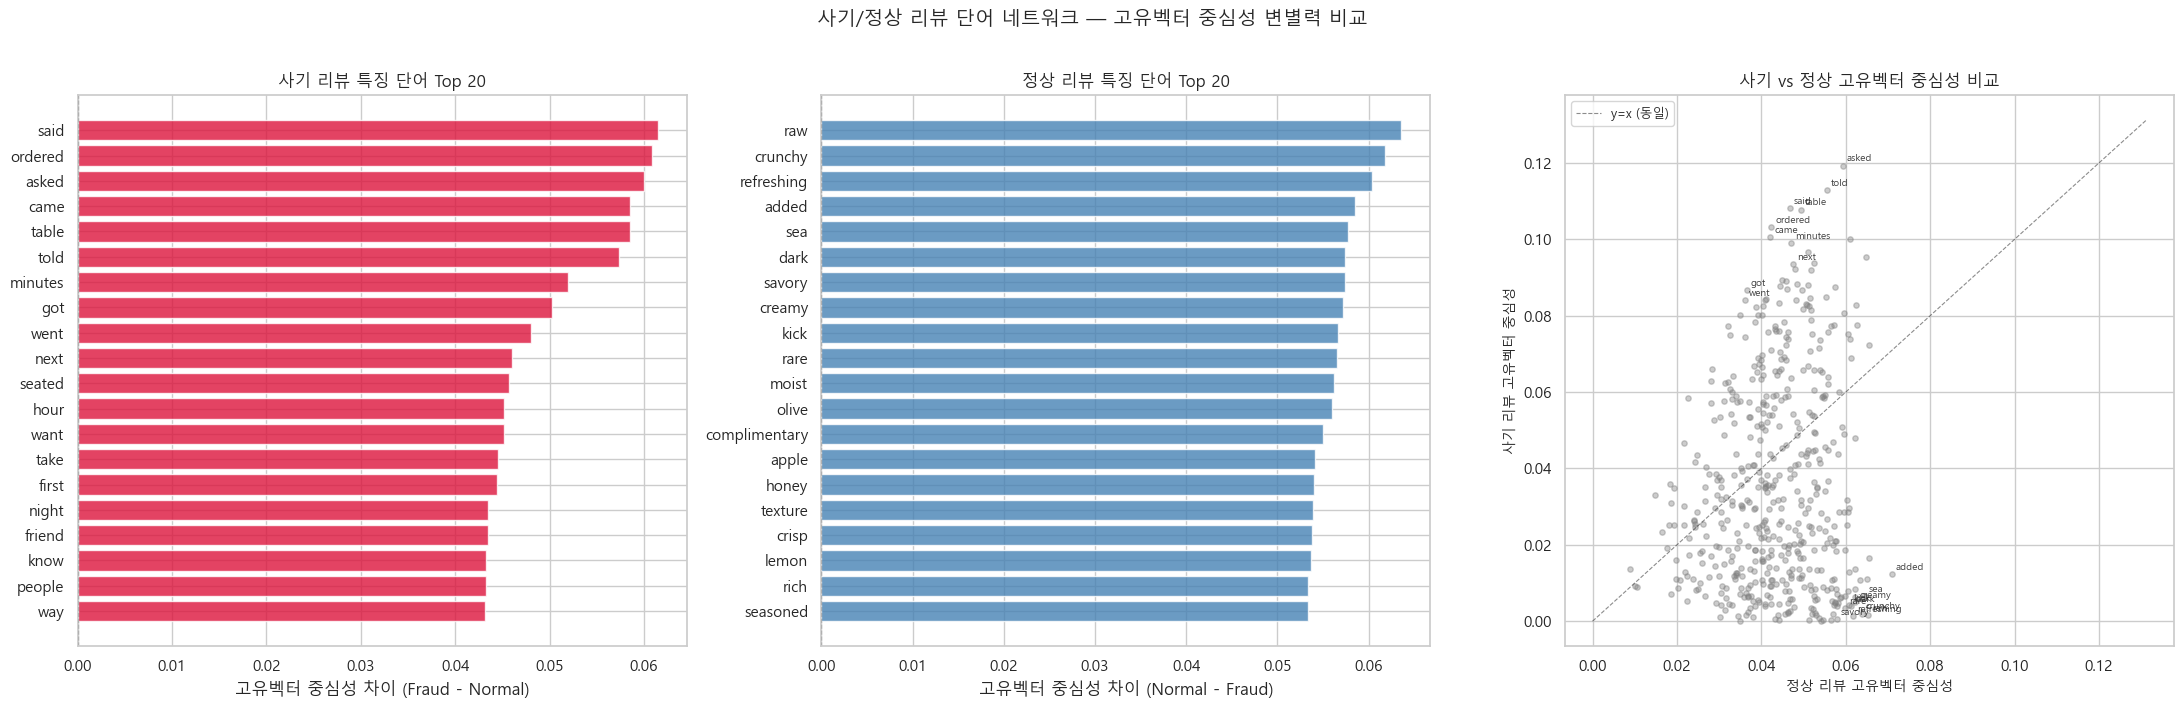

=== 변별력 상위 40개 단어 ===
           단어  사기_고유벡터  정상_고유벡터  차이(F-N) 특징
          raw  0.00165  0.06525 -0.06359 정상
      crunchy  0.00197  0.06373 -0.06176 정상
         said  0.10819  0.04673  0.06146 사기
      ordered  0.10312  0.04225  0.06086 사기
   refreshing  0.00128  0.06164 -0.06036 정상
        asked  0.11929  0.05928  0.06000 사기
        added  0.01234  0.07087 -0.05853 정상
         came  0.10055  0.04204  0.05851 사기
        table  0.10776  0.04928  0.05848 사기
          sea  0.00664  0.06441 -0.05778 정상
         dark  0.00388  0.06133 -0.05745 정상
       savory  0.00047  0.05786 -0.05739 정상
         told  0.11286  0.05553  0.05733 사기
       creamy  0.00496  0.06219 -0.05723 정상
         kick  0.00420  0.06086 -0.05667 정상
         rare  0.00336  0.05988 -0.05652 정상
        moist  0.00037  0.05654 -0.05617 정상
        olive  0.00622  0.06222 -0.05601 정상
complimentary  0.00196  0.05693 -0.05497 정상
        apple  0.00040  0.05456 -0.05416 정상
        honey  0.00015  0.05419 -0.05404 정상
      text

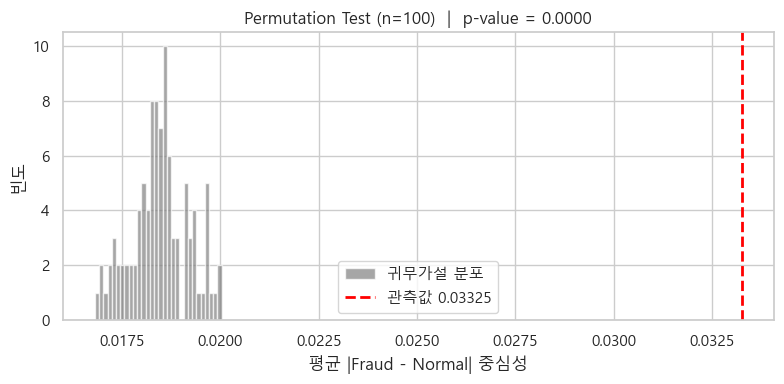

  귀무가설 분포: 평균 0.01846 +/- 0.00072
  p-value: 0.0000
  결론: [유의] 통계적으로 유의미 (p < 0.05)


In [6]:
if eigen_fraud and eigen_normal:
    TOP_N = 20

    all_words   = set(eigen_fraud) | set(eigen_normal)
    diff        = {w: eigen_fraud.get(w, 0) - eigen_normal.get(w, 0) for w in all_words}

    fraud_char  = sorted(diff.items(), key=lambda x:  x[1], reverse=True)[:TOP_N]
    normal_char = sorted(diff.items(), key=lambda x:  x[1])[:TOP_N]

    fig, axes = plt.subplots(1, 3, figsize=(22, 7))

    fw, fv = zip(*fraud_char)
    axes[0].barh(fw[::-1], fv[::-1], color='crimson', alpha=0.8)
    axes[0].set_title(f"사기 리뷰 특징 단어 Top {TOP_N}", fontsize=12)
    axes[0].set_xlabel("고유벡터 중심성 차이 (Fraud - Normal)")
    axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')

    nw, nv = zip(*normal_char)
    nv_abs = [-v for v in nv]
    axes[1].barh(nw[::-1], nv_abs[::-1], color='steelblue', alpha=0.8)
    axes[1].set_title(f"정상 리뷰 특징 단어 Top {TOP_N}", fontsize=12)
    axes[1].set_xlabel("고유벡터 중심성 차이 (Normal - Fraud)")
    axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')

    common = list(set(eigen_fraud) & set(eigen_normal))
    axes[2].scatter(
        [eigen_normal[w] for w in common],
        [eigen_fraud[w]  for w in common],
        alpha=0.4, s=15, color='gray'
    )
    top_diff_words = set([w for w, _ in fraud_char[:10]] + [w for w, _ in normal_char[:10]])
    for w in common:
        if w in top_diff_words:
            axes[2].annotate(w, (eigen_normal[w], eigen_fraud[w]),
                             fontsize=7, alpha=0.9,
                             xytext=(3, 3), textcoords='offset points')
    lim = max(max(eigen_fraud.values(), default=0.1), max(eigen_normal.values(), default=0.1)) * 1.1
    axes[2].plot([0, lim], [0, lim], 'k--', linewidth=0.8, alpha=0.5, label='y=x (동일)')
    axes[2].set_xlabel("정상 리뷰 고유벡터 중심성", fontsize=10)
    axes[2].set_ylabel("사기 리뷰 고유벡터 중심성", fontsize=10)
    axes[2].set_title("사기 vs 정상 고유벡터 중심성 비교", fontsize=12)
    axes[2].legend(fontsize=9)

    plt.suptitle("사기/정상 리뷰 단어 네트워크 — 고유벡터 중심성 변별력 비교", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    diff_df = pd.DataFrame([
        {
            "단어":        w,
            "사기_고유벡터": eigen_fraud.get(w, 0),
            "정상_고유벡터": eigen_normal.get(w, 0),
            "차이(F-N)":   diff[w],
            "특징":        "사기" if diff[w] > 0 else "정상",
        }
        for w in all_words
    ]).sort_values("차이(F-N)", key=abs, ascending=False).reset_index(drop=True)

    print(f"=== 변별력 상위 {TOP_N * 2}개 단어 ===")
    print(diff_df.head(TOP_N * 2).to_string(index=False, float_format=lambda x: f"{x:.5f}"))

    discriminative_vocab = set(diff_df.head(100)["단어"].tolist())
    print(f"\n→ HIN 커스텀 엣지 구축용 변별 어휘 {len(discriminative_vocab)}개 저장 (discriminative_vocab)")

    # Permutation Test: train 서브샘플만 사용 — 누수 방지
    print("\n=== Permutation Test (n=100, 서브샘플 5,000개 기반) ===")
    print("레이블을 무작위로 섞어 귀무가설 분포를 추정합니다... (수 분 소요)")

    N_PERMS     = 100
    PERM_SAMPLE = 5000

    # train 행만으로 서브샘플 — test 정보 차단
    df_perm_base = df_train_sample.sample(
        min(PERM_SAMPLE, len(df_train_sample)), random_state=0
    ).reset_index(drop=True)

    G_obs_f = build_pmi_network(list(df_perm_base[df_perm_base["label"] == 1]["clean_text"]),
                                top_words, min_count=10)
    G_obs_n = build_pmi_network(list(df_perm_base[df_perm_base["label"] == 0]["clean_text"]),
                                top_words, min_count=10)
    ef_obs  = safe_eigen(G_obs_f)
    en_obs  = safe_eigen(G_obs_n)

    if ef_obs and en_obs:
        all_words_perm = list(set(ef_obs) | set(en_obs))
        observed_stat  = np.mean([abs(ef_obs.get(w, 0) - en_obs.get(w, 0))
                                   for w in all_words_perm])
    else:
        all_words_perm = []
        observed_stat  = 0.0
    print(f"  관측 통계량: {observed_stat:.5f}")

    null_stats = []
    for i in range(N_PERMS):
        perm_labels   = np.random.permutation(df_perm_base['label'].values)
        df_p          = df_perm_base.copy()
        df_p['label'] = perm_labels

        G_pf = build_pmi_network(list(df_p[df_p['label'] == 1]['clean_text']), top_words, min_count=10)
        G_pn = build_pmi_network(list(df_p[df_p['label'] == 0]['clean_text']), top_words, min_count=10)
        ef   = safe_eigen(G_pf)
        en   = safe_eigen(G_pn)

        if ef and en:
            all_w = list(set(ef) | set(en))
            null_stats.append(np.mean([abs(ef.get(w, 0) - en.get(w, 0)) for w in all_w]))

        if (i + 1) % 20 == 0:
            print(f"  [{i+1}/{N_PERMS}] 완료")

    if null_stats:
        null_arr = np.array(null_stats)
        p_value  = float((null_arr >= observed_stat).mean())

        plt.figure(figsize=(8, 4))
        plt.hist(null_arr, bins=30, color='gray', alpha=0.7, label='귀무가설 분포')
        plt.axvline(observed_stat, color='red', linestyle='--', linewidth=2,
                    label=f'관측값 {observed_stat:.5f}')
        plt.xlabel("평균 |Fraud - Normal| 중심성")
        plt.ylabel("빈도")
        plt.title(f"Permutation Test (n={N_PERMS})  |  p-value = {p_value:.4f}")
        plt.legend()
        plt.tight_layout()
        plt.show()

        print(f"  귀무가설 분포: 평균 {null_arr.mean():.5f} +/- {null_arr.std():.5f}")
        print(f"  p-value: {p_value:.4f}")
        print(f"  결론: {'[유의] 통계적으로 유의미 (p < 0.05)' if p_value < 0.05 else '[비유의] 통계적으로 유의하지 않음 (p >= 0.05)'}")
    else:
        print("  유효한 permutation 결과 없음.")
else:
    print("eigen_fraud 또는 eigen_normal이 없습니다. 앞 셀을 먼저 실행하세요.")

In [7]:
# ── 섹션 5 준비: 전체 2,826개 어휘 풀에서 변별 어휘 300개 추출 ───────────────
# EDA용 G_full(~103개)과 독립적으로, freq≥100 전체 2,826개 어휘 기반
# 사기/정상 PMI 네트워크를 재구성해 변별 어휘 풀을 충분히 확보

print("=== 변별 어휘 300개 추출 (전체 2,826개 풀 기준) ===")
top_words_full = [w for w, cnt in _freq.items() if cnt >= 100]
print(f"전체 풀: {len(top_words_full)}개 어휘")

G_fraud_full  = build_pmi_network(df_fraud['clean_text'],  top_words_full, min_count=10)
G_normal_full = build_pmi_network(df_normal['clean_text'], top_words_full, min_count=10)
print(f"사기 전체 네트워크: 노드 {G_fraud_full.number_of_nodes():,}, 엣지 {G_fraud_full.number_of_edges():,}")
print(f"정상 전체 네트워크: 노드 {G_normal_full.number_of_nodes():,}, 엣지 {G_normal_full.number_of_edges():,}")

eigen_fraud_full  = safe_eigen(G_fraud_full)
eigen_normal_full = safe_eigen(G_normal_full)

all_words_full = set(eigen_fraud_full) | set(eigen_normal_full)
diff_full = {
    w: eigen_fraud_full.get(w, 0) - eigen_normal_full.get(w, 0)
    for w in all_words_full
}

disc_vocab_300 = sorted(diff_full, key=lambda w: abs(diff_full[w]), reverse=True)[:300]

print(f"\n변별 어휘 300개 확정 (|사기 - 정상| 고유벡터 중심성 차이 기준)")
print(f"  사기 특징 상위 5개: {[w for w in disc_vocab_300 if diff_full[w] > 0][:5]}")
print(f"  정상 특징 상위 5개: {[w for w in disc_vocab_300 if diff_full[w] < 0][:5]}")
print(f"\n→ 섹션 5 TF-IDF 어휘로 사용 (EDA용 103개 어휘와 독립적으로 결정됨)")

=== 변별 어휘 300개 추출 (전체 2,826개 풀 기준) ===
전체 풀: 2011개 어휘
사기 전체 네트워크: 노드 1,551, 엣지 50,604
정상 전체 네트워크: 노드 2,011, 엣지 533,564

변별 어휘 300개 확정 (|사기 - 정상| 고유벡터 중심성 차이 기준)
  사기 특징 상위 5개: ['asked', 'told', 'manager', 'said', 'table']
  정상 특징 상위 5개: ['topped', 'texture', 'creamy', 'soft', 'added']

→ 섹션 5 TF-IDF 어휘로 사용 (EDA용 103개 어휘와 독립적으로 결정됨)


## 5. HIN 커스텀 엣지 생성 (R-TextSim-R)

**변별 어휘 300개** (전체 2,826개 풀에서 사기/정상 고유벡터 중심성 차이 상위)로 TF-IDF를 구성하고, 전체 50,950개 리뷰에 대해 청크 연산으로 텍스트 유사도 기반 커스텀 엣지를 생성합니다.

**설계 원리 (개선):**
1. **EDA 어휘(~103개)와 분리**: TF-IDF 어휘는 2,826개 풀에서 별도 선택 — 순환 논리 해소
2. **300차원 TF-IDF**: 충분한 벡터 표현으로 코사인 유사도 0.85가 실질적인 필터로 작동
3. **청크 연산으로 전체 커버**: 5,000개 샘플링 대신 전체 리뷰 50,950개에 엣지 생성
4. **Chi-square + Cramér's V**로 엣지 유형 분포의 통계적 유효성 검증

> **이전 대비 개선 사항**: EDA 네트워크(섹션 3) 필터링 결과(103개)를 TF-IDF 어휘로 재사용하던 순환 구조를 깨고, 2,826개 전체 풀에서 독립적으로 변별 어휘를 선정합니다. 300차원 벡터로 희소성 문제를 해결하고, 청크 연산으로 GNN 학습에 필요한 전체 커버리지를 확보합니다.

커스텀 엣지 기반 어휘: 300개 (train 기반 전체 2,826개 풀의 변별 상위 300개)
TF-IDF 행렬 생성 완료: (50950, 300)  (리뷰 수 x 변별 어휘 수)

청크 코사인 유사도 계산 시작 (전체 50,950개, 청크 2000개 단위)...
  진행: 10,000/50,950 (19.6%)
  진행: 20,000/50,950 (39.3%)
  진행: 30,000/50,950 (58.9%)
  진행: 40,000/50,950 (78.5%)
  진행: 50,000/50,950 (98.1%)
  진행: 50,950/50,950 (100.0%)

=== R-TextSim-R 커스텀 엣지 생성 결과 ===
  커버 리뷰: 50,950개 (전체 100%)
  생성된 엣지 수: 159,835개  (임계값 >= 0.85)
  엣지 밀도: 0.0123%

엣지 유형 분포:
edge_type
Mixed            77869
Fraud-Fraud      43277
Normal-Normal    38689

=== 엣지 유효성 통계 검증 ===
  Chi-square = 148143.8,  p-value = 0.00e+00
  Cramér's V = 0.6808  (강한 연관)

  유형별 기댓값 vs 관측값:
    Fraud-Fraud    : 기댓       9867  관측      43277  비율 4.386 [▲ 많음]
    Normal-Normal  : 기댓      90277  관측      38689  비율 0.429 [▼ 적음]
    Mixed          : 기댓      59691  관측      77869  비율 1.305 [▲ 많음]


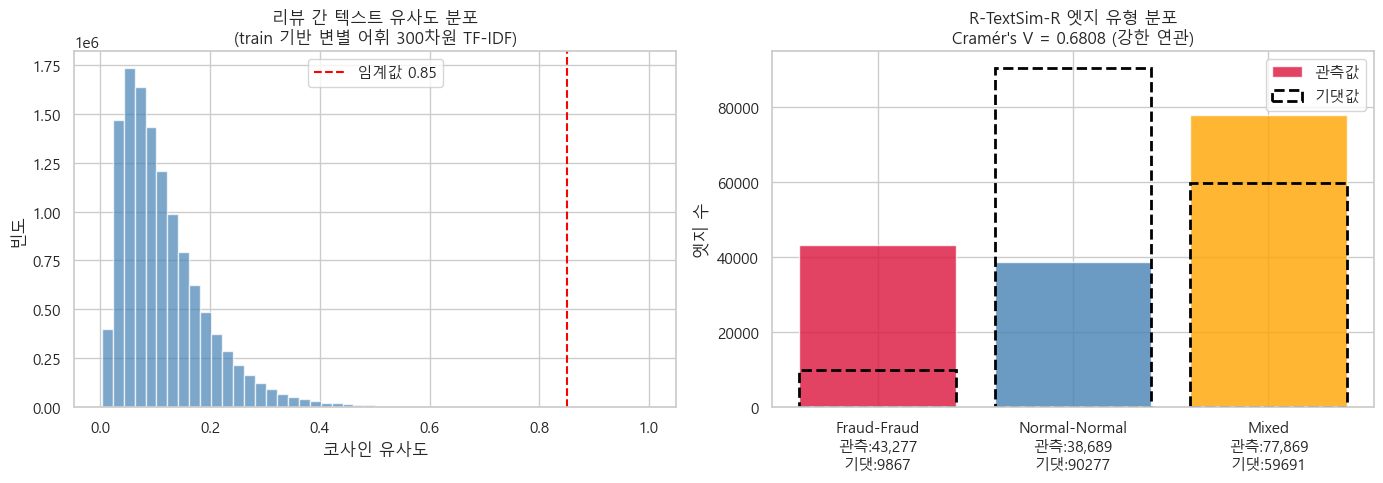


→ 커스텀 엣지 파일 저장 완료: custom_edges_textSim.csv
→ 다음 HIN 구축 노트북에서 R-TextSim-R 엣지로 불러와 사용하세요.


In [8]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import chisquare

# 1. 변별 어휘 300개로 TF-IDF 구성
print(f"커스텀 엣지 기반 어휘: {len(disc_vocab_300)}개 (train 기반 전체 2,826개 풀의 변별 상위 300개)")

df_sample = df_sample.reset_index(drop=True)
tfidf_refined = TfidfVectorizer(vocabulary=disc_vocab_300)

# IDF 계산: train 행만 사용 — 누수 방지
tfidf_refined.fit(df_sample[df_sample['_is_train']]['clean_text'])
# 전체 리뷰에 transform (transductive GNN 엣지 생성에는 전체 노드가 필요)
tfidf_matrix = tfidf_refined.transform(df_sample['clean_text'])
print(f"TF-IDF 행렬 생성 완료: {tfidf_matrix.shape}  (리뷰 수 x 변별 어휘 수)")

# 2. 청크 연산으로 전체 50,950개 리뷰 커버
SIM_THRESHOLD = 0.85
CHUNK_SIZE    = 2000
n             = tfidf_matrix.shape[0]
mat           = tfidf_matrix.toarray()
lbl_all       = df_sample['label'].to_numpy()

print(f"\n청크 코사인 유사도 계산 시작 (전체 {n:,}개, 청크 {CHUNK_SIZE}개 단위)...")
edges_list = []

for i in range(0, n, CHUNK_SIZE):
    chunk_end = min(i + CHUNK_SIZE, n)
    block = cosine_similarity(mat[i:chunk_end], mat)

    for local_i in range(chunk_end - i):
        block[local_i, : i + local_i + 1] = 0

    r, c = np.where(block >= SIM_THRESHOLD)
    if len(r):
        edges_list.append(pd.DataFrame({
            'src_review_idx': r + i,
            'dst_review_idx': c,
            'text_similarity': block[r, c],
            'src_label':       lbl_all[r + i],
            'dst_label':       lbl_all[c],
        }))

    if (i // CHUNK_SIZE + 1) % 5 == 0 or chunk_end == n:
        print(f"  진행: {chunk_end:,}/{n:,} ({chunk_end / n * 100:.1f}%)")

custom_edges_df = pd.concat(edges_list, ignore_index=True) if edges_list else pd.DataFrame()

print(f"\n=== R-TextSim-R 커스텀 엣지 생성 결과 ===")
print(f"  커버 리뷰: {n:,}개 (전체 100%)")
print(f"  생성된 엣지 수: {len(custom_edges_df):,}개  (임계값 >= {SIM_THRESHOLD})")

if len(custom_edges_df) > 0:
    density = len(custom_edges_df) / (n * (n - 1) / 2)
    print(f"  엣지 밀도: {density:.4%}")

    custom_edges_df['edge_type'] = custom_edges_df.apply(
        lambda r: 'Fraud-Fraud'   if r['src_label'] == 1 and r['dst_label'] == 1
             else 'Normal-Normal' if r['src_label'] == 0 and r['dst_label'] == 0
             else 'Mixed', axis=1
    )
    print("\n엣지 유형 분포:")
    print(custom_edges_df['edge_type'].value_counts().to_string())

    p_fraud  = float((lbl_all == 1).sum()) / n
    p_normal = 1.0 - p_fraud
    total_e  = len(custom_edges_df)

    categories = ['Fraud-Fraud', 'Normal-Normal', 'Mixed']
    expected = {
        'Fraud-Fraud':   p_fraud  ** 2          * total_e,
        'Normal-Normal': p_normal ** 2          * total_e,
        'Mixed':         2 * p_fraud * p_normal * total_e,
    }
    ec  = custom_edges_df['edge_type'].value_counts()
    obs = np.array([ec.get(k, 0) for k in categories], dtype=float)
    exp = np.array([expected[k]  for k in categories], dtype=float)

    chi2_stat, p_val = chisquare(obs, f_exp=exp)
    cramers_v = np.sqrt(chi2_stat / (total_e * (len(categories) - 1)))
    v_label   = '약한 연관' if cramers_v < 0.1 else ('중간 연관' if cramers_v < 0.3 else '강한 연관')

    print(f"\n=== 엣지 유효성 통계 검증 ===")
    print(f"  Chi-square = {chi2_stat:.1f},  p-value = {p_val:.2e}")
    print(f"  Cramér's V = {cramers_v:.4f}  ({v_label})")
    print(f"\n  유형별 기댓값 vs 관측값:")
    for k, o, e in zip(categories, obs, exp):
        ratio = o / e if e > 0 else float('nan')
        arrow = '[▲ 많음]' if ratio > 1 else '[▼ 적음]'
        print(f"    {k:15s}: 기댓 {e:>10.0f}  관측 {o:>10.0f}  비율 {ratio:.3f} {arrow}")

    sample_n = min(5000, n)
    sim_sample = cosine_similarity(mat[:sample_n])
    np.fill_diagonal(sim_sample, 0)
    nonzero_sim = sim_sample[sim_sample > 0].ravel()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(nonzero_sim, bins=50, color='steelblue', alpha=0.7)
    axes[0].axvline(SIM_THRESHOLD, color='red', linestyle='--', label=f'임계값 {SIM_THRESHOLD}')
    axes[0].set_xlabel("코사인 유사도")
    axes[0].set_ylabel("빈도")
    axes[0].set_title(f"리뷰 간 텍스트 유사도 분포\n(train 기반 변별 어휘 {len(disc_vocab_300)}차원 TF-IDF)")
    axes[0].legend()

    color_map  = {'Fraud-Fraud': 'crimson', 'Normal-Normal': 'steelblue', 'Mixed': 'orange'}
    bar_labels = [f"{k}\n관측:{int(o):,}\n기댓:{e:.0f}" for k, o, e in zip(categories, obs, exp)]
    axes[1].bar(bar_labels, obs, color=[color_map[k] for k in categories], alpha=0.8, label='관측값')
    axes[1].bar(bar_labels, exp, color='none', edgecolor='black', linewidth=2, linestyle='--', label='기댓값')
    axes[1].set_ylabel("엣지 수")
    axes[1].set_title(f"R-TextSim-R 엣지 유형 분포\nCramér's V = {cramers_v:.4f} ({v_label})")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    save_cols = ['src_review_idx', 'dst_review_idx', 'text_similarity']
    custom_edges_df[save_cols].to_csv('custom_edges_textSim.csv', index=False)
    print(f"\n→ 커스텀 엣지 파일 저장 완료: custom_edges_textSim.csv")
    print(f"→ 다음 HIN 구축 노트북에서 R-TextSim-R 엣지로 불러와 사용하세요.")
else:
    print(f"\n임계값 {SIM_THRESHOLD}에서 생성된 엣지가 없습니다. SIM_THRESHOLD를 낮춰 보세요.")

사기 특징 어휘: 102개 | 정상 특징 어휘: 198개
vocab 피처 계산 중... (전체 리뷰 적용)

사기 대표 키워드 (상위 5): ['asked', 'told', 'manager', 'said', 'table']
정상 대표 키워드 (상위 5): ['topped', 'texture', 'creamy', 'soft', 'added']

=== label별 피처 평균 (train 기준) ===
       fraud_intensity  normal_intensity  vocab_discrim  kw_asked  kw_told  kw_manager  kw_said  kw_table  kw_topped  kw_texture  kw_creamy  kw_soft  kw_added
label                                                                                                                                                         
0               0.1788            0.0624         0.1163    0.0417   0.0364      0.0094   0.0720    0.1421     0.0206      0.0345     0.0299   0.0439    0.0243
1               0.1801            0.0325         0.1476    0.0374   0.0334      0.0254   0.0471    0.0816     0.0035      0.0053     0.0058   0.0084    0.0088


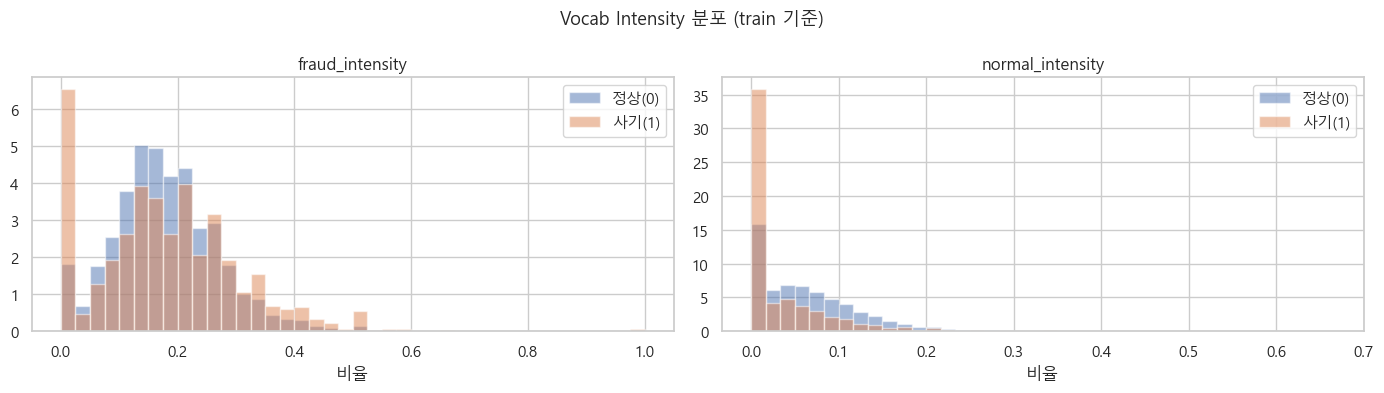


✅ 변별 어휘 피처 저장: features_text_vocab.csv  (50950, 14)
   피처 목록 (13개): ['fraud_intensity', 'normal_intensity', 'vocab_discrim', 'kw_asked', 'kw_told', 'kw_manager', 'kw_said', 'kw_table', 'kw_topped', 'kw_texture', 'kw_creamy', 'kw_soft', 'kw_added']


In [9]:
# ── Phase 1: 변별 어휘 기반 노드 피처 생성 ────────────────────────────────────
# disc_vocab_300, diff_full: 위 셀에서 train 데이터만으로 계산됨 → 누수 없음
# 피처 기준(단어풀)이 train 기반이고, 수치화는 단어 존재 여부만 보므로
# test 리뷰에 적용해도 라벨 정보가 섞이지 않음 (fit=train, transform=all)

# 1. 사기/정상 특징 어휘 분리
fraud_words  = set(w for w in disc_vocab_300 if diff_full[w] > 0)
normal_words = set(w for w in disc_vocab_300 if diff_full[w] < 0)
print(f"사기 특징 어휘: {len(fraud_words)}개 | 정상 특징 어휘: {len(normal_words)}개")

# 2. vocab 강도 계산 (리뷰 단어 중 해당 어휘 비중)
def vocab_intensity(text, vocab_set):
    words = str(text).split()
    if not words:
        return 0.0
    return sum(1 for w in words if w in vocab_set) / len(words)

print("vocab 피처 계산 중... (전체 리뷰 적용)")
df_sample = df_sample.reset_index(drop=True)
df_sample['fraud_intensity']  = df_sample['clean_text'].apply(
    lambda t: vocab_intensity(t, fraud_words))
df_sample['normal_intensity'] = df_sample['clean_text'].apply(
    lambda t: vocab_intensity(t, normal_words))
# vocab_discrim: 단일 판별 신호 (양수=사기 성향, 음수=정상 성향)
df_sample['vocab_discrim'] = df_sample['fraud_intensity'] - df_sample['normal_intensity']

# 3. Top 10 이진 키워드 피처 (사기 특징 상위 5개 + 정상 특징 상위 5개)
top_fraud_kw  = sorted(fraud_words,  key=lambda w: diff_full[w],  reverse=True)[:5]
top_normal_kw = sorted(normal_words, key=lambda w: diff_full[w])[:5]
print(f"\n사기 대표 키워드 (상위 5): {top_fraud_kw}")
print(f"정상 대표 키워드 (상위 5): {top_normal_kw}")

for kw in top_fraud_kw + top_normal_kw:
    df_sample[f'kw_{kw}'] = df_sample['clean_text'].apply(lambda t: int(kw in t.split()))

kw_cols   = [f'kw_{kw}' for kw in top_fraud_kw + top_normal_kw]
feat_cols = ['fraud_intensity', 'normal_intensity', 'vocab_discrim'] + kw_cols

# 4. 유효성 확인: train 기준 label별 피처 평균
print("\n=== label별 피처 평균 (train 기준) ===")
df_tr = df_sample[df_sample['_is_train']]
print(df_tr[feat_cols + ['label']].groupby('label').mean().round(4).to_string())

# 분포 시각화 (intensity 2개)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, color in zip(axes, ['fraud_intensity', 'normal_intensity'], ['crimson', 'steelblue']):
    for lbl, grp in df_tr.groupby('label'):
        ax.hist(grp[col], bins=40, alpha=0.5,
                label=f"{'사기' if lbl==1 else '정상'}({lbl})", density=True)
    ax.set_title(col); ax.set_xlabel("비율"); ax.legend()
plt.suptitle("Vocab Intensity 분포 (train 기준)", fontsize=13)
plt.tight_layout()
plt.show()

# 5. 저장 (user_id 포함 → 05에서 행 순서 검증용)
features_vocab = df_sample[['user_id'] + feat_cols].copy()
features_vocab.to_csv('features_text_vocab.csv')
print(f"\n✅ 변별 어휘 피처 저장: features_text_vocab.csv  {features_vocab.shape}")
print(f"   피처 목록 ({len(feat_cols)}개): {feat_cols}")